# Global waves — significant wave height

Demonstrates the **3-hourly wave-field pattern**: pull a few days of the
global wave reanalysis (MFWAM) significant wave height `VHM0` over the
North Atlantic, then show both a snapshot map and a point time-series
through a winter storm.

Dataset `cmems_mod_glo_wav_my_0.2deg_PT3H-i` is a multi-year reanalysis
(stable historical coverage) on a 0.2° grid with a 3-hourly step, so a
fixed date works fine here.

Reads credentials from `COPERNICUSMARINE_SERVICE_USERNAME` /
`COPERNICUSMARINE_SERVICE_PASSWORD`.

In [1]:
import os
from pathlib import Path

import xarray as xr
from pyramids.netcdf import NetCDF

from earthlens import EarthLens
from earthlens.cmems import Catalog

OUT_DIR = Path('data/cmems-wave')
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ID = 'cmems_mod_glo_wav_my_0.2deg_PT3H-i'
POINT_LAT, POINT_LON = 48.0, -16.0  # NE Atlantic, west of Brittany

ds_meta = Catalog().get_dataset(DATASET_ID)
print(f'{DATASET_ID}: domain={ds_meta.domain}, cadence={ds_meta.cadence}')
print('VHM0 units:', ds_meta.variables['VHM0'].units)

2026-05-20 19:43:16 | INFO | pyramids.base.config | Logging is configured.


cmems_mod_glo_wav_my_0.2deg_PT3H-i: domain=global, cadence=irregular
VHM0 units: m


## Download three days over the North Atlantic

3-hourly × 3 days = 24 time steps of a 2-D field over a ~25°×15° box.

In [2]:
el = EarthLens(
    data_source='cmems',
    start='2014-02-08',
    end='2014-02-10',
    cadence='hourly',
    dataset=DATASET_ID,
    variables=['VHM0'],
    aoi=[-30.0, 40.0, -5.0, 55.0],
    path=str(OUT_DIR),
    service_username=os.environ.get('COPERNICUSMARINE_SERVICE_USERNAME'),
    service_password=os.environ.get('COPERNICUSMARINE_SERVICE_PASSWORD'),
)
paths = el.download()
print(paths)

INFO - 2026-05-20T17:43:19Z - Checking if credentials are valid.


2026-05-20 17:43:19 | INFO | copernicusmarine | Checking if credentials are valid.


INFO - 2026-05-20T17:43:20Z - Valid credentials from input username and password.


2026-05-20 17:43:20 | INFO | copernicusmarine | Valid credentials from input username and password.


2026-05-20 19:43:20.410 | INFO     | earthlens.cmems.backend:_subset_one:458 - Requesting CMEMS subset for 'cmems_mod_glo_wav_my_0.2deg_PT3H-i' variables=['VHM0'] → cmems_mod_glo_wav_my_0.2deg_PT3H-i.nc


...

2026-05-20 17:43:21 | INFO | copernicusmarine | Selected dataset part: "default"


INFO - 2026-05-20T17:43:23Z - Total size of the download: 331.44 KB.


2026-05-20 17:43:23 | INFO | copernicusmarine | Total size of the download: 331.44 KB.


2026-05-20 19:43:23.516 | INFO     | earthlens.cmems.backend:download:326 - CMEMS download summary: 1 files written to C:\gdrive\algorithms\remote-sensing\earthlens\docs\examples\cmems\data\cmems-wave


[WindowsPath('C:/gdrive/algorithms/remote-sensing/earthlens/docs/examples/cmems/data/cmems-wave/cmems_mod_glo_wav_my_0.2deg_PT3H-i.nc')]


## Open the field and pull a point series

In [3]:
nc = NetCDF.read_file(str(paths[0]), read_only=True)
ds = xr.decode_cf(nc.to_xarray())
nc.close()
print('dims:', dict(ds.sizes))
vhm0 = ds['VHM0']
point = vhm0.sel(latitude=POINT_LAT, longitude=POINT_LON, method='nearest')
peak = point.max()
print(f'peak Hs at ({POINT_LAT}N, {abs(POINT_LON)}W): {float(peak):.1f} m')

dims: {'time': 17, 'latitude': 76, 'longitude': 126}
peak Hs at (48.0N, 16.0W): 12.5 m


## Snapshot map + point time-series

Left: the significant-wave-height field at the stormiest step. Right:
the 3-hourly Hs series at the chosen point as the storm passes.

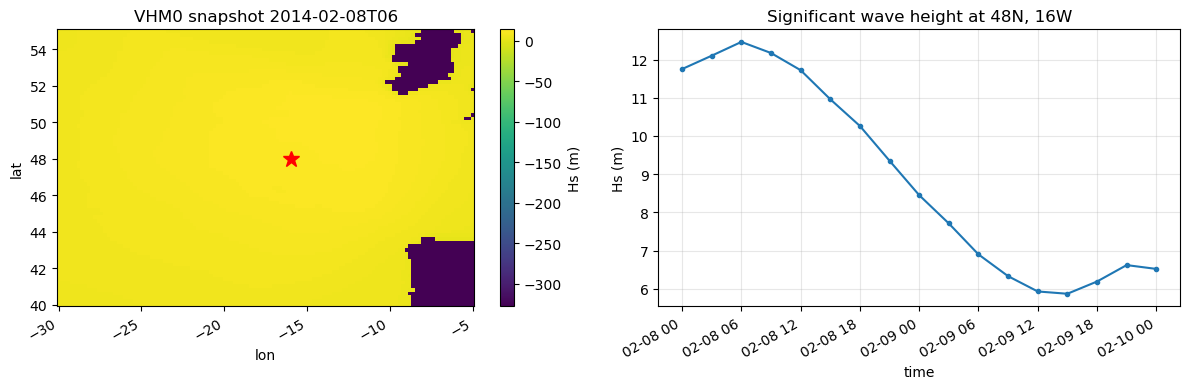

In [4]:
import matplotlib.pyplot as plt

peak_step = int(point.argmax('time'))
snapshot = vhm0.isel(time=peak_step)

fig, (axm, axt) = plt.subplots(1, 2, figsize=(12, 4))
mesh = axm.pcolormesh(
    snapshot['longitude'].values,
    snapshot['latitude'].values,
    snapshot.values,
    cmap='viridis',
    shading='auto',
)
fig.colorbar(mesh, ax=axm, label='Hs (m)')
axm.plot([POINT_LON], [POINT_LAT], 'r*', markersize=12)
axm.set_title(f'VHM0 snapshot {str(snapshot["time"].values)[:13]}')
axm.set_xlabel('lon')
axm.set_ylabel('lat')

axt.plot(point['time'].values, point.values, marker='o', ms=3)
axt.set_title('Significant wave height at 48N, 16W')
axt.set_ylabel('Hs (m)')
axt.set_xlabel('time')
axt.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()